# Analyzing WY2017 (baseline) model output, includes:
- Storage change assessment
- Calculation of evaporative fraction for the WY
- Transpiration analysis
- Recharge area analysis
- Recharge magnitude spatial analysis
- Calculation of daily soil moisture changes
- Comparison of SWE and wilting point area against WY2017 warming scenario


In [1]:
import os
import sys
from datetime import datetime
from parflow.tools import Run
from parflow.tools.fs import mkdir, cp, get_absolute_path, exists
from parflow.tools.settings import set_working_directory
import numpy as np
import matplotlib.pyplot as plt
from parflow.tools.io import read_pfb,write_pfb, read_clm
import calendar
from glob import glob

from parflow import Run
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import rasterio as rst 
import parflow.tools.hydrology as hydro
from parflow.tools.io import read_pfb,write_pfb, read_clm
import parflow.tools.hydrology as hydro
import random
import os
import calendar
import xarray as xr
from matplotlib import colors 
import matplotlib.dates as mdates
import parflow as pf


In [2]:
"""
Creating the run object from the pdifb and getting grid size and shape. 
Then creating data accessor object ("data = ...")
"""
runname = 'East_taylor_newbounds_1.wy2017'
path_run = f'/hydrodata/temp/EastTaylor_ashley/{runname}/'

run = Run.from_definition(f'{path_run}{runname}.pfidb')
run.Solver.CLM.MetFilePath = '/home/ad4430/sr_thesis/EastTaylor_inputs/resubset/newbounds_CW3E_WY2017'

data = run.data_accessor # creating data accessor object 
dx = data.dx
dy = data.dy
dz = data.dz
na,ny,nx = data.shape

porosity= data.computed_porosity
specific_storage = data.specific_storage
mask = data.mask
mask[mask>0]=1 # PF has big # instead of 1 so change to 1 bc more manageable
surf_mask = mask[-1,:,:] # last element of first axis (always be surface no matter what)

nanmask=mask.copy()
nanmask[nanmask == 0] = 'NaN'
nanmask[nanmask > 0] = 1

if run.Mannings.Type == 'PFBFile':
    mannings = np.squeeze(read_pfb(f'{path_run}{run.Mannings.FileName}'))
elif run.Mannings.Type == 'Constant':
    mannings = run.Mannings.Geom.domain.Value
slopex = np.squeeze(data.slope_x)
slopey = np.squeeze(data.slope_y)

# for converting from LE to ET
rho_w = 997 # kg/m3
h_vap = 22.6*10**5 # J/kg

print(dx, dy)

nanmask=mask.copy()
nanmask[nanmask == 0] = 'NaN'
nanmask[nanmask > 0] = 1

Solver: Field BinaryOutDir is not part of the expected schema <class 'parflow.tools.database.generated.Solver'>
  - nt
  - sw_ini
  - hkdepth
  - wtfact
  - trsmx0
  - smpmax
  - pondmx
1000 1000


/home/SHARED/virtual-environments/parflow-shared/conda/lib/python3.11/site-packages/parflow/tools/io.py:1300: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_name, delim_whitespace=True, skiprows=2, header=None)


## Storage change assessment

In [3]:
"""
getting storage and fluxes

only run once to save out arrays, load in the next cell
"""

year = 2017
if calendar.isleap(year) == False:

    num_tsteps = 8760+1
else: 
    num_tsteps = 8784+1


surface_storage = np.zeros(num_tsteps)
subsurface_storage = np.zeros(num_tsteps)
et_sum = np.zeros(num_tsteps)
precip = np.zeros(num_tsteps)
overland_out = np.zeros(num_tsteps)
swe = np.zeros(num_tsteps)


for t in range(0,num_tsteps):
    
    # tstep_range[-1]
    data.time = t
    pressure = data.pressure 
    saturation = data.saturation

    subsurface_storage[t] = np.sum(hydro.calculate_subsurface_storage(porosity, pressure, saturation, specific_storage, dx,dy,dz, mask=mask),axis=(0,1,2))
    surface_storage[t] = np.sum(hydro.calculate_surface_storage(pressure, dx, dy, mask=mask), axis=(0,1))
    overland_out[t] = hydro.calculate_overland_flow(pressure, slopex, slopey, mannings, dx, dy, flow_method=run.Patch.top.BCPressure.Type,mask=mask)


                                
    if t > 0: 
        data.forcing_time = t-1
        precip[t] = np.sum(data.clm_forcing('APCP')[surf_mask==1])#*(3600/1000)*(dx)*(dy) # get rid of unit conversions
        et_sum[t]  = np.sum(data.clm_output('eflx_lh_tot')[surf_mask==1])*(1/rho_w)*(1/h_vap)#*(3600/1000)*(dx)*(dy)
        swe[t]  = np.sum(data.clm_output('swe_out')[surf_mask==1])#*(1/1000)*(dx)*(dy)
    

np.save("subsurface_wy2017_1", subsurface_storage)
np.save("surface_wy2017_1", surface_storage)
np.save("overland_out_wy2017_1",  overland_out)

np.save("precip_wy2017_1", precip)
np.save("et_wy2017_1", et_sum)
np.save("swe_wy2017_1", swe)


In [6]:
# load in arrays from prev cell
# number corresponds to which 2017 run (1 being WY2003 IC)
subsurface_storage_1 = np.load("subsurface_wy2017_1.npy") # m3
surface_storage_1 = np.load("surface_wy2017_1.npy") # m3

precip_1 = np.load("precip_wy2017_1.npy") # mm/hr, multiply by 3600 seconds in 1 hour, 1000mm in 1m, dx dy
et_1 = np.load("et_wy2017_1.npy") # m/s, multiply by dx dy
swe_1 = np.load("swe_wy2017_1.npy") # mm, multiply by 1000m in 1m, dx dy


In [7]:
# converting so everything is in m3
precip_m3_hr_1 = precip_1*(3600/1000)*(dx)*(dy)
et_m3_hr_1 = et_1*3600*dx*dy
swe_m3_1 = swe_1*(1/1000)*dx*dy


In [12]:
# change in storage btwn start and end of run
storage_change_1 = (subsurface_storage_1[-1] + surface_storage_1[-1]) - (subsurface_storage_1[0] + surface_storage_1[0])
print("change in storage, WY2017 run 1 = ", storage_change_1)

# precip - et
pme_1 = np.sum(precip_m3_hr_1) - np.sum(et_m3_hr_1)
print("precip - et, WY2017 run 1 = ", pme_1)

#normalized storage change
norm_storage_change_1 = storage_change_1 / pme_1
print("normalized change in storage, WY2017 run 1 = ", norm_storage_change_1)

change in storage, WY2017 run 1 =  7927310.4228134155
precip - et, WY2017 run 1 =  7927310.4228134155
normalized change in storage, WY2017 run 1 =  0.017204621066861835


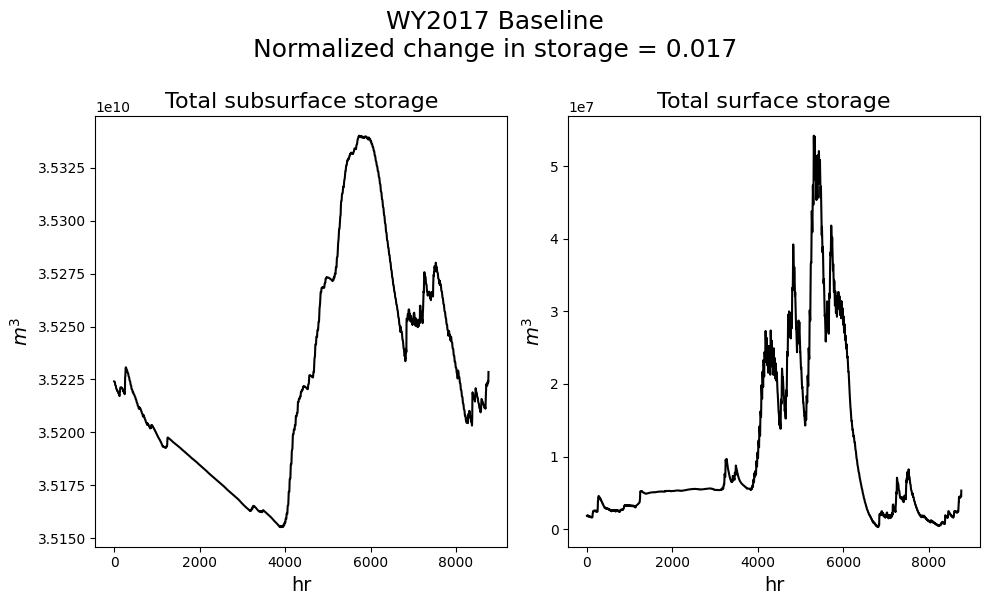

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))
fig.suptitle(f"WY2017 Baseline\nNormalized change in storage = {np.round(norm_storage_change_1, 3)}", y = 1.0, fontsize = 18)
axs[0].plot(subsurface_storage_1, c = 'black')
axs[0].set_title("Total subsurface storage", fontsize = 16)
axs[0].set_ylabel("$m^3$", fontsize = 14)
axs[0].set_xlabel("hr", fontsize = 14)
#axs[0].text(0,0, ("storage change, normalized by P - ET = ", norm_storage_change_4))

axs[1].plot(surface_storage_1, c = 'black')
axs[1].set_title("Total surface storage", fontsize = 16)
axs[1].set_ylabel("$m^3$", fontsize = 14)
axs[1].set_xlabel("hr", fontsize = 14)

plt.tight_layout()

plt.savefig("/home/ad4430/sr_thesis/EastTaylor_outputs/WY2017_newbounds/plots/storage_run1.png")

## getting DEM and land cover info

(1, 48, 67)

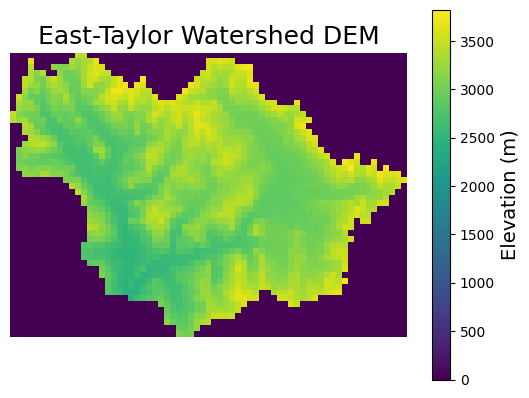

In [3]:
dem = read_pfb("/home/ad4430/sr_thesis/EastTaylor_inputs/resubset/DEM_newbounds_EastTaylor.pfb")
# mask = read_pfb("/home/ad4430/sr_thesis/EastTaylor_inputs/resubset/allfiles_WY2017/mask.pfb")
# mask[mask == 0] = np.nan
plt.imshow(dem[0]*mask[0], origin = 'lower')
plt.title('East-Taylor Watershed DEM', fontsize = 18)
plt.axis("off")
cbar = plt.colorbar()
cbar.set_label('Elevation (m)', fontsize = 14)
dem.shape


In [9]:
new_header = ['x', 'y', 'lat', 'lon', 'sand', 'clay', 'color', 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]  

vegm = pd.read_csv('/home/ad4430/sr_thesis/EastTaylor_inputs/resubset/newbounds_WY2017/drv_vegm.csv', delimiter=',', skiprows = 2, names = new_header)

vegm

,x,y,lat,lon,sand,clay,color,1,2,3,...,9,10,11,12,13,14,15,16,17,18
0,1,1,38.584524,-107.062561,0.43,0.19,5,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,38.585682,-107.050826,0.59,0.16,5,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,38.586839,-107.039091,0.45,0.20,5,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,1,38.587995,-107.027355,0.41,0.19,5,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,1,38.589149,-107.015619,0.47,0.19,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3211,63,48,39.085625,-106.399371,0.66,0.11,5,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3212,64,48,39.086708,-106.387529,0.67,0.11,5,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3213,65,48,39.087790,-106.375687,0.67,0.11,5,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3214,66,48,39.088870,-106.363845,0.67,0.11,5,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
vegm = vegm.drop(['lat', 'lon', 'sand', 'clay', 'color'], axis = 1)
vegm.head()

,x,y,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,3,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,5,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0


In [11]:
landcover_columns = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18] # List of your landcover columns
x_col = 'x'
y_col = 'y'

vegm['landcover_type'] = vegm[landcover_columns].idxmax(axis=1)

landcover_map = vegm.pivot(index=y_col, columns=x_col, values='landcover_type')

landcover_map = landcover_map.astype(int) 
landcover_map.shape



(48, 67)

nan


Text(0.5, 1.0, 'Landcover in the East-Taylor Watershed')

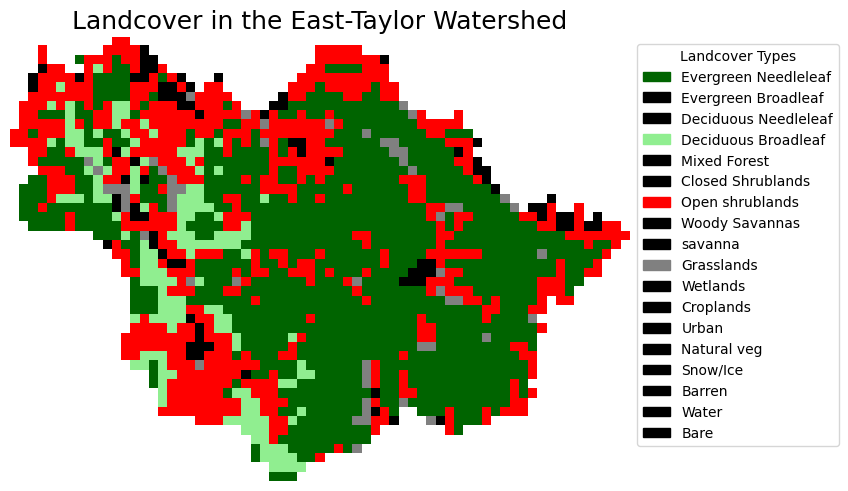

In [12]:
import matplotlib.patches as mpatches
nanmask=mask.copy()
nanmask[nanmask == 0] = 'NaN'
nanmask[nanmask > 0] = 1

landcover_names = {
    1: 'Evergreen Needleleaf', 2: 'Evergreen Broadleaf', 3: 'Deciduous Needleleaf', 4: 'Deciduous Broadleaf', 5: 'Mixed Forest', 
    6: 'Closed Shrublands', 7: 'Open shrublands', 8: 'Woody Savannas', 9: 'savanna', 10: 'Grasslands', 
    11: 'Wetlands', 12: 'Croplands', 13: 'Urban', 14: 'Natural veg', 15: 'Snow/Ice', 
    16: 'Barren', 17: 'Water', 18: 'Bare'
}

landcover_colors = {
    1: 'darkgreen', 2: 'black', 3: 'black', 4: 'lightgreen', 5: 'black', 
    6: 'black', 7: 'red', 8: 'black', 9: 'black', 10: 'gray', 
    11: 'black', 12: 'black', 13: 'black', 14: 'black', 15: 'black', 
    16: 'black', 17: 'black', 18: 'black'
}

landcover_map = landcover_map.astype(int)  

landcover_map_masked = landcover_map*nanmask[0]
landcover_map_masked.head()
print(landcover_map_masked.loc[1,1])

plt.figure(figsize=(8, 6))

cmap = plt.cm.colors.ListedColormap(list(landcover_colors.values()))
bounds = np.arange(0, 19, 1) 
norm = plt.Normalize(vmin=1, vmax=18)

plt.imshow(np.ma.masked_array(landcover_map_masked.values, mask[-1,:,:]==0), interpolation='nearest', cmap=cmap, norm=norm, origin = 'lower')

handles = [mpatches.Patch(color=color, label=landcover_names[landcover_type]) 
           for landcover_type, color in landcover_colors.items()]
plt.legend(handles=handles, title="Landcover Types", loc='upper left', bbox_to_anchor=(1, 1))
plt.axis('off')
plt.title("Landcover in the East-Taylor Watershed", fontsize = 18)

## Full WY Analysis: precip, temp, et, and evaporative fraction

In [ ]:
# calculating total precip and et at each cell
precip_tot = np.zeros((ny,nx))
et_tot = np.zeros((ny,nx))

num_tsteps = 8760+1

 # 2d array for precip at particular timestep for each cell - does this exist???? is precip the same for each cell?
precip_timestep = np.zeros((ny,nx))
et_timestep = np.zeros((ny,nx))

for t in range(0,num_tsteps):
    data.time = t

    
    if t > 0: 
        data.forcing_time = t-1
        # 2d array for that particular timestep
        precip_timestep= data.clm_forcing_apcp*3600
        
        # array of the cumulative precip at each grid cell
        precip_tot += precip_timestep


        et_timestep = data.clm_output('eflx_lh_tot') * (1 / rho_w) * (1 / h_vap)*3600*1000  # converting from m/s to mm/hr 

        et_tot += et_timestep

np.save("precip_tot", precip_tot)
np.save("domain_et_tot", et_tot)

In [ ]:
# calculating avg temp
num_tsteps = 8760+1
temp_timestep = np.zeros((num_tsteps, ny,nx))

for t in range(0,num_tsteps):
    data.time = t

    if t > 0: 
        data.forcing_time = t-1
        # 2d array for that particular timestep
        temp_timestep[t-1,:,:]= data.clm_forcing_temp

avg_temp = np.mean(temp_timestep)
avg_temp_C = avg_temp - 273.15
avg_temp_domain = np.mean(temp_timestep, axis = 0)
avg_temp_domain.shape

np.save("avg_temp_domain", avg_temp_domain)

In [ ]:
# precip over the domain (ny,nx)
precip_tot = np.load("precip_tot.npy")
precip_tot.shape
precip_avg = np.mean(precip_tot)

plt.imshow(np.ma.masked_array(precip_tot, surf_mask == 0), origin = 'lower')
plt.title('Total Precip (mm), WY2017')
plt.colorbar()
plt.axis('off')
print(f'avg precip per grid cell = {precip_avg}')
plt.savefig("/home/ad4430/sr_thesis/EastTaylor_outputs/WY2017_newbounds/plots/precip_map.png")

In [ ]:
# total volume of precip, summing over all timesteps
precip_m3 = np.sum(precip_m3_hr_1)
precip_m3

# this is total et, summing over all timesteps
et_m3 = np.sum(et_m3_hr_1)


# this is the fraction of ET/P using cumulative volumes over entire domain
evap_frac_domain = et_m3/precip_m3
print(evap_frac_domain)

In [ ]:
# spatial analysis of evaporative fraction
yr_et_tot = np.load("domain_et_tot.npy")

yr_evap_index = yr_et_tot/precip_tot
yr_elim_area = 0
yr_wlim_area = 0
for y in range (0, ny):
    for x in range (0,nx):
        if yr_evap_index[y,x] >= 1 and yr_evap_index[y,x] <=5:
            yr_wlim_area +=1
        elif yr_evap_index[y,x] < 1 and yr_evap_index[y,x] >=0:
            yr_elim_area+=1

norm_evap_index = colors.TwoSlopeNorm(vmin=0, vcenter=1, vmax=yr_evap_index.max())

plt.imshow(np.ma.masked_array(yr_evap_index, surf_mask==0),origin='lower', norm = norm_evap_index, cmap = 'PuOr_r')
plt.colorbar()
plt.axis('off')
plt.text(0,-3, f"water limited area = {yr_wlim_area} $km^2$")
plt.text(0,-5.5, f"energy limited area = {yr_elim_area} $km^2$")
plt.title('ET/P, WY2017')

plt.savefig("/home/ad4430/sr_thesis/EastTaylor_outputs/WY2017_newbounds/plots/evap_index.png")

## SWE Analysis

In [20]:
swe = np.load("swe_wy2017_1.npy")
swe = swe*(1/1000)*dx*dy
len(swe)

8761

In [21]:
swe_warm = np.load('/home/ad4430/sr_thesis/EastTaylor_outputs/1.5inc_WY2017_newbounds/WY2003_IC/swe_wy2017_1.npy')
swe_warm = swe_warm*(1/1000)*dx*dy


Text(0, 0.5, '$m^3$')

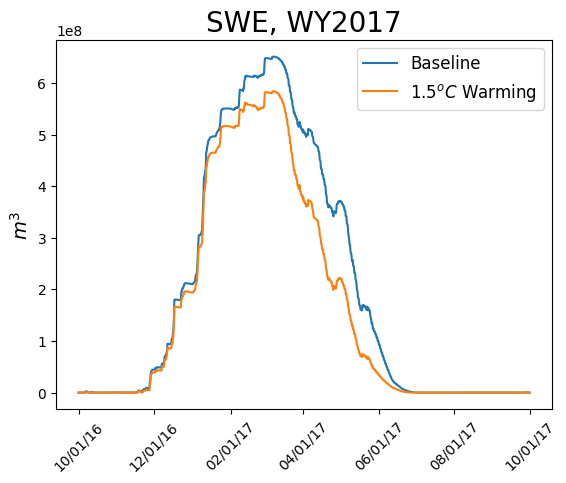

In [29]:
start_date = '2016-10-01'
end_date = '2017-10-01'  

dates = pd.date_range(start=start_date, end=end_date, freq='h')

plt.plot(dates, swe, label='Baseline')
plt.plot(dates, swe_warm, label='$1.5^oC$ Warming')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))   # First of each month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m/%d/%y')) 

plt.xticks(rotation=45)

plt.legend(fontsize = 12)
plt.title('SWE, WY2017', fontsize = 20)
plt.ylabel('$m^3$', fontsize = 14)


In [15]:
for i in range (len(swe)):
    if i > 3000 and swe[i] == 0:
        melt_hr_og = i
        print('hr no swe, original = ', melt_hr_og)
        break

hr no swe, original =  6663


In [16]:
for i in range (len(swe)):
    if i > 3000 and swe_warm[i] == 0:
        melt_hr_warm = i
        print('hr no swe, warm = ', melt_hr_warm)
        break

hr no swe, warm =  6476


In [18]:
print((melt_hr_og - melt_hr_warm)/24)

7.791666666666667


# Summer Analysis (July-September)

In [32]:
# 273 days between 10/1/2002 and 7/1/2003
# 62 days until 9/1/2003 from the start of july
summer_tstart = 273*24 # hour in the WY that july starts
summer_tend = (273+62)*24 # hour marking the start of september
summer_numtsteps = summer_tend - summer_tstart + 1

summer_precip_tot = np.zeros((ny,nx))
summer_precip_timestep = np.zeros((ny,nx))

summer_temp = np.zeros((summer_numtsteps, ny, nx))

for t in range(0, summer_numtsteps):
    data.time = t + summer_tstart # first index will be first hour of july

    data.forcing_time = t + summer_tstart - 1 
    
    # 2d array for that particular timestep
    summer_precip_timestep= data.clm_forcing_apcp*3600
    
    # array of the cumulative precip at each grid cell
    summer_precip_tot += summer_precip_timestep

    summer_temp[t,:,:] = data.clm_forcing_temp

summer_temp_tavg = np.mean(summer_temp, axis = 0)

np.save("summer_precip_tot", summer_precip_tot)
np.save("summer_temp_tavg", summer_temp_tavg)

In [34]:
summer_temp_tavg = np.load("summer_temp_tavg.npy")
summer_temp_tavg.shape

(48, 67)

## wilting point area before and after warming

In [26]:
summer_sat_10cm = np.zeros((summer_numtsteps, ny, nx)) 
summer_sat_40cm = np.zeros((summer_numtsteps, ny, nx)) 
summer_sat_1m = np.zeros((summer_numtsteps, ny, nx))

for t in range(0, summer_numtsteps):
    data.time = t + summer_tstart # first index will be first hour of july

    summer_sat_10cm[t] = data.saturation[9,:,:]
    summer_sat_40cm[t] = data.saturation[8,:,:]
    summer_sat_1m[t] = data.saturation[7,:,:]

np.save("summer_sat_10cm", summer_sat_10cm)
np.save("summer_sat_40cm", summer_sat_30cm)
np.save("summer_sat_1m", summer_sat_60cm)

In [31]:
summer_sat_10cm = np.load("summer_sat_10cm.npy") 
summer_sat_40cm = np.load("summer_sat_40cm.npy")
summer_sat_1m = np.load("summer_sat_1m.npy")

# from warming simulation
summer_sat_10cm_warm = np.load("/home/ad4430/sr_thesis/EastTaylor_outputs/1.5inc_WY2017_newbounds/WY2003_IC/summer_sat_10cm.npy")
summer_sat_40cm_warm = np.load("/home/ad4430/sr_thesis/EastTaylor_outputs/1.5inc_WY2017_newbounds/WY2003_IC/summer_sat_40cm.npy")
summer_sat_1m_warm = np.load("/home/ad4430/sr_thesis/EastTaylor_outputs/1.5inc_WY2017_newbounds/WY2003_IC/summer_sat_1m.npy")

In [32]:
percent_wilting =  np.zeros(summer_numtsteps)
percent_wilting_warm =  np.zeros(summer_numtsteps)

for i in range (summer_numtsteps):
    num_wilting = 0
    num_wilting_warm = 0
    for y in range (ny):
        for x in range (nx):
            summer_sat_10cm[i,:,:] = summer_sat_10cm[i,:,:]*nanmask[0]
            summer_sat_40cm[i,:,:] = summer_sat_40cm[i,:,:]*nanmask[0]
            summer_sat_1m[i,:,:] = summer_sat_1m[i,:,:]*nanmask[0]

            summer_sat_10cm_warm[i,:,:] = summer_sat_10cm_warm[i,:,:]*nanmask[0]
            summer_sat_40cm_warm[i,:,:] = summer_sat_40cm_warm[i,:,:]*nanmask[0]
            summer_sat_1m_warm[i,:,:] = summer_sat_1m_warm[i,:,:]*nanmask[0]
            
            if summer_sat_10cm[i,y,x] < 0.2:
                num_wilting +=1

            if summer_sat_10cm_warm[i,y,x] < 0.2:
                num_wilting_warm +=1

    percent_wilting[i] = num_wilting/1883
    percent_wilting_warm[i] = num_wilting_warm/1883





0.06319702602230483
0.07275624004248539


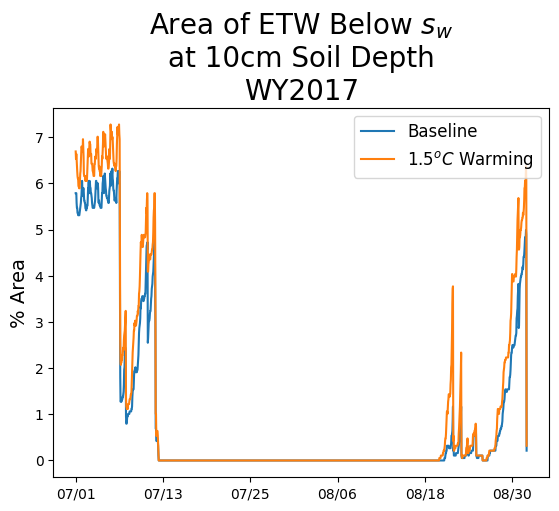

In [44]:
start_date = '2017-07-01'
end_date = '2017-09-01'  

dates = pd.date_range(start=start_date, end=end_date, freq='h')


plt.plot(dates,percent_wilting*100, label = 'Baseline')
plt.plot(dates, percent_wilting_warm*100, label = '$1.5^oC$ Warming')
plt.legend(fontsize = 12, loc = 'upper right')
plt.ylabel('% Area', fontsize = 14)
plt.title('Area of ETW Below $s_w$\nat 10cm Soil Depth\nWY2017', fontsize = 20)

plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=12))  
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m/%d')) 

print(percent_wilting.max())
print(percent_wilting_warm.max())

## Gather output for ET, Transpiration, Soil moisture, Infilitration, WTD

In [43]:
# 273 days between 10/1/2002 and 7/1/2003
# 62 days until 9/1/2003 from the start of july

summer_tstart = 273*24 # hour in the WY that july starts
summer_tend = (273+62)*24 # hour marking the start of september
summer_numtsteps = summer_tend - summer_tstart + 1

# arrays to hold soil moisture values at each time for each grid cell at varying depths
summer_sm_10cm = np.zeros((summer_numtsteps, ny, nx)) 
summer_sm_40cm = np.zeros((summer_numtsteps, ny, nx)) 
summer_sm_1m = np.zeros((summer_numtsteps, ny, nx)) 
summer_sm_2m = np.zeros((summer_numtsteps, ny, nx)) 
summer_sm_7m = np.zeros((summer_numtsteps, ny, nx)) 

# arrays to hold cumulative et and t at each grid cell
summer_et_sum = np.zeros((ny, nx))
summer_tran_sum = np.zeros((ny, nx))

# cumulative ground infiltration at each grid cell over the summer
summer_infl_sum = np.zeros((ny, nx))

# looping over july-september
for t in range(0, summer_numtsteps):
    data.time = t + summer_tstart # first index will be first hour of july

    # soil moisture at each time step for each grid cell (unitless)
    summer_sm_10cm[t] = data.saturation[9,:,:]*porosity[9,:,:] 
    summer_sm_40cm[t] = data.saturation[8,:,:]*porosity[8,:,:] 
    summer_sm_1m[t] = data.saturation[7,:,:]*porosity[7,:,:] 
    summer_sm_2m[t] = data.saturation[6,:,:]*porosity[6,:,:] 
    summer_sm_7m[t] = data.saturation[5,:,:]*porosity[5,:,:] 

    
    # 2d arrays for et and t at that particular timestep
    et_timestep = data.clm_output('eflx_lh_tot') * (1 / rho_w) * (1 / h_vap)*3600*1000  # converting from m/s to mm/hr 
    tran_timestep = data.clm_output('qflx_tran_veg') * 3600  # converting from mm/s to mm/hr

    #total et and t for each grid cell
    summer_et_sum += et_timestep
    summer_tran_sum += tran_timestep


    # 2d infiltration array for that particular timestep
    infl_timestep = data.clm_output('qflx_infl')*3600 # converting from mm/s to mm/hr

    # total infiltration for each grid cell
    summer_infl_sum += infl_timestep



np.save("summer_sm_10cm", summer_sm_10cm)
np.save("summer_sm_40cm", summer_sm_40cm)
np.save("summer_sm_1m", summer_sm_1m)
np.save("summer_sm_2m", summer_sm_2m)
np.save("summer_sm_7m", summer_sm_7m)

np.save("summer_et_sum", summer_et_sum)
np.save("summer_tran_sum", summer_tran_sum)

np.save("summer_infl_sum", summer_infl_sum)


KeyboardInterrupt: 

98.23297197821185


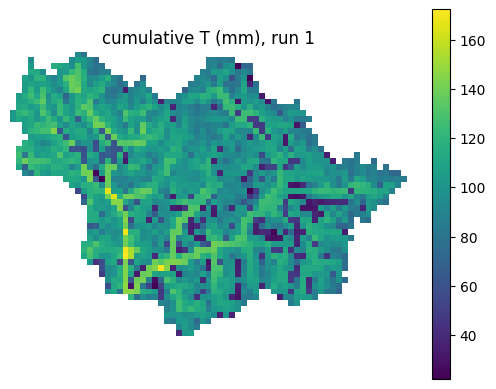

In [6]:
t_tot_summer = np.load("summer_tran_sum.npy")
plt.imshow(np.ma.masked_array(t_tot_summer, surf_mask==0),origin='lower')
plt.colorbar()
plt.axis('off')
plt.title('cumulative T (mm), run 1')
basin_avg_t = np.nanmean(t_tot_summer*nanmask)
print(basin_avg_t)


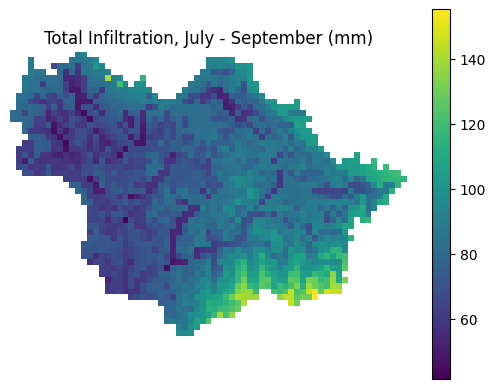

In [35]:
# total infiltration in the summer
plt.imshow(np.ma.masked_array(summer_infl_sum, surf_mask==0),origin='lower')
plt.colorbar()
plt.axis('off')
plt.title('Total Infiltration, July - September (mm)')

plt.savefig("/home/ad4430/sr_thesis/EastTaylor_outputs/WY2017_newbounds/plots/summer/infil_sum.png")

Text(0.5, 1.0, '$T_{warm}$ - $T_{baseline}$')

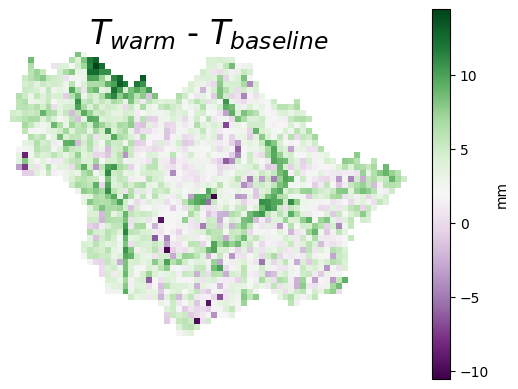

In [8]:
# change in transpiration before and after warming
t_tot_summer_warm = np.load('/home/ad4430/sr_thesis/EastTaylor_outputs/1.5inc_WY2017_newbounds/WY2003_IC/summer_tran_sum.npy') # from warming simulation
twarm_tbaseline = t_tot_summer_warm - t_tot_summer
im = plt.imshow(np.ma.masked_array(twarm_tbaseline, surf_mask==0), origin='lower', cmap='PRGn')

cbar = plt.colorbar(im)
cbar.set_label('mm')  

plt.axis('off')
plt.title('$T_{warm}$ - $T_{baseline}$', fontsize = 24)

In [19]:
# percent of grid cells with increase in transpiration after warming
twarm_tbaseline = twarm_tbaseline*nanmask[0]
tran_inc = 0
for y in range(ny):
    for x in range(nx):
        if twarm_tbaseline[y,x] > 0:
            tran_inc+=1

tran_perc_inc = tran_inc/1883
print(tran_perc_inc)

0.9054699946893255


In [21]:
# water table depth

summer_wtd = np.zeros((summer_numtsteps, ny, nx))

#list all pressure files from outputs
press_files = glob(f'{path_run}/*out.press*.pfb')
#read in all pressure files into a 3D NParray
pressure_arrays = pf.read_pfb_sequence(press_files) * nanmask

# #list all saturation files from outputs
satur_files = glob(f'{path_run}/*out.satur*.pfb')
#read in all pressure files into a 3D NParray
saturation_arrays = pf.read_pfb_sequence(satur_files) * nanmask

for t in range(0,summer_numtsteps):
    
    # tstep_range[-1]
    data.time = t + summer_tstart
    summer_pressure = data.pressure 
    summer_saturation = data.saturation


data.time = 0

for i, (summer_pressure, summer_saturation) in enumerate(zip(pressure_arrays, saturation_arrays)):
    summer_wtd[i, ...] = hydro.calculate_water_table_depth(summer_pressure, summer_saturation, dz)
    
    data.time = i

IndexError: index 1489 is out of bounds for axis 0 with size 1489

In [18]:
summer_wtd_avg = np.mean(summer_wtd, axis = 0)

np.save("summer_wtd_avg", summer_wtd_avg)

NameError: name 'summer_wtd' is not defined

In [6]:
summer_wtd_avg = np.load("summer_wtd_avg.npy")

## Daily SM change analysis

In [6]:
# average saturation between each layer
summer_avg_10_40 = (summer_sm_10cm + summer_sm_40cm)/2


summer_avg_40_1 = (summer_sm_40cm + summer_sm_1m)/2


summer_avg_1_2 = (summer_sm_1m + summer_sm_2m)/2


summer_avg_2_7 = (summer_sm_2m + summer_sm_7m)/2


In [14]:
### calculate daily changes in soil moisture, then take average of daily changes
summer_numdays = int((summer_numtsteps - 1)/24) # each timestep is an hr
# loop over time, find difference between i+1 and i 
summer_dailydS_10_40 = np.zeros((summer_numdays, ny,nx))
summer_dailydS_40_1 = np.zeros((summer_numdays, ny,nx))
summer_dailydS_1_2 = np.zeros((summer_numdays, ny,nx))
summer_dailydS_2_7 = np.zeros((summer_numdays, ny,nx))

for day in range(0, summer_numdays-1):
    hr = day*24

    #multiplying by depths of segment to get units of length (mm)
    summer_dailydS_10_40[day,:,:] = (summer_avg_10_40[hr+24, :,:] - summer_avg_10_40[hr, :,:])*300 
    summer_dailydS_40_1[day,:,:] = (summer_avg_40_1[hr+24, :,:] - summer_avg_40_1[hr, :,:])*600
    summer_dailydS_1_2[day,:,:] = (summer_avg_1_2[hr+24, :,:] - summer_avg_1_2[hr, :,:])*1000
    summer_dailydS_2_7[day,:,:] = (summer_avg_2_7[hr+24, :,:] - summer_avg_2_7[hr, :,:])*5000



# find average daily difference over time for each grid cell
summer_avgdailydS_10_40 = np.mean(summer_dailydS_10_40, axis = 0)
summer_avgdailydS_40_1 = np.mean(summer_dailydS_40_1, axis = 0)
summer_avgdailydS_1_2 = np.mean(summer_dailydS_1_2, axis = 0)
summer_avgdailydS_2_7 = np.mean(summer_dailydS_2_7, axis = 0)



Text(0.5, 1.1, 'Average Daily Soil Moisture Change\nWY2017 July - September\n\n▲S$_{baseline}$')

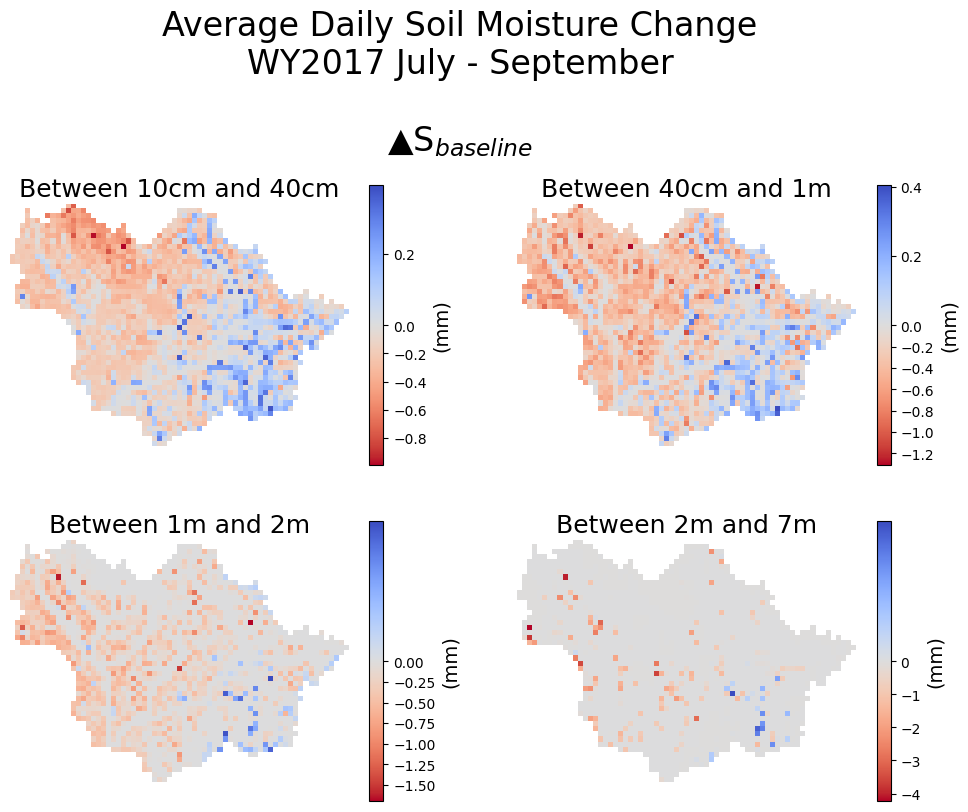

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
norm_10_40 = colors.TwoSlopeNorm(vmin=summer_avgdailydS_10_40.min(), vcenter=0, vmax=summer_avgdailydS_10_40.max())
norm_40_1 = colors.TwoSlopeNorm(vmin=summer_avgdailydS_40_1.min(), vcenter=0, vmax=summer_avgdailydS_40_1.max())
norm_1_2 = colors.TwoSlopeNorm(vmin=summer_avgdailydS_1_2.min(), vcenter=0, vmax=summer_avgdailydS_1_2.max())
norm_2_7 = colors.TwoSlopeNorm(vmin=summer_avgdailydS_2_7.min(), vcenter=0, vmax=summer_avgdailydS_2_7.max())

im1 = axs[0,0].imshow(np.ma.masked_array(summer_avgdailydS_10_40, surf_mask == 0), origin='lower', cmap = 'coolwarm_r', norm = norm_10_40)
axs[0,0].set_title('Between 10cm and 40cm', fontsize = 18)
axs[0,0].axis('off')
cbar = fig.colorbar(im1, ax=axs[0,0])
cbar.set_label('(mm)', fontsize=14)
#axs[0,0].text(0.5,-2.7, f'basin average change = {np.round(summer_avgdailydS_10_40.mean(), 3)} mm', size=10)

im2 = axs[0,1].imshow(np.ma.masked_array(summer_avgdailydS_40_1, surf_mask == 0), origin='lower', cmap = 'coolwarm_r', norm = norm_40_1)
axs[0,1].set_title('Between 40cm and 1m', fontsize  = 18)
axs[0,1].axis('off')
cbar = fig.colorbar(im2, ax=axs[0,1])
cbar.set_label('(mm)', fontsize=14)
#axs[0,1].text(0.5,-2.7, f'basin average change = {np.round(summer_avgdailydS_40_1.mean(), 3)} mm', size=10)

im3 = axs[1,0].imshow(np.ma.masked_array(summer_avgdailydS_1_2, surf_mask == 0), origin='lower', cmap = 'coolwarm_r', norm = norm_1_2)
axs[1,0].set_title('Between 1m and 2m', fontsize = 18)
axs[1,0].axis('off')
cbar = fig.colorbar(im3, ax=axs[1,0])
cbar.set_label('(mm)', fontsize=14)
#axs[1,0].text(0.5,-2.7, f'basin average change = {np.round(summer_avgdailydS_1_2.mean(), 3)} mm', size=10)


im4 = axs[1,1].imshow(np.ma.masked_array(summer_avgdailydS_2_7, surf_mask == 0), origin='lower', cmap = 'coolwarm_r', norm = norm_2_7)
axs[1,1].set_title('Between 2m and 7m', fontsize = 18)
axs[1,1].axis('off')
cbar = fig.colorbar(im4, ax=axs[1,1])
cbar.set_label('(mm)', fontsize=14)
#axs[1,1].text(0.5,-2.7, f'basin average change = {np.round(summer_avgdailydS_2_7.mean(), 3)} mm', size=10)

fig.suptitle('Average Daily Soil Moisture Change\nWY2017 July - September\n\n\u25B2S$_{baseline}$', fontsize = 24, y = 1.1)

## recharge analysis

In [15]:
# finding area of basin with positive I-T (recharge area)
# each pixel is 1km, so just sum pixels for recharge area

diff_infil_T = (summer_infl_sum - summer_tran_sum)*nanmask[0]


recharge_area = 0
for y in range (0, ny):
    for x in range (0,nx):
        if diff_infil_T[y,x] >= 0:
            recharge_area +=1

print(recharge_area)


504


In [16]:
print(np.nanmin(diff_infil_T))
print(np.nanmax(diff_infil_T))

-112.00099373119227
111.55531418416751


(48, 67)

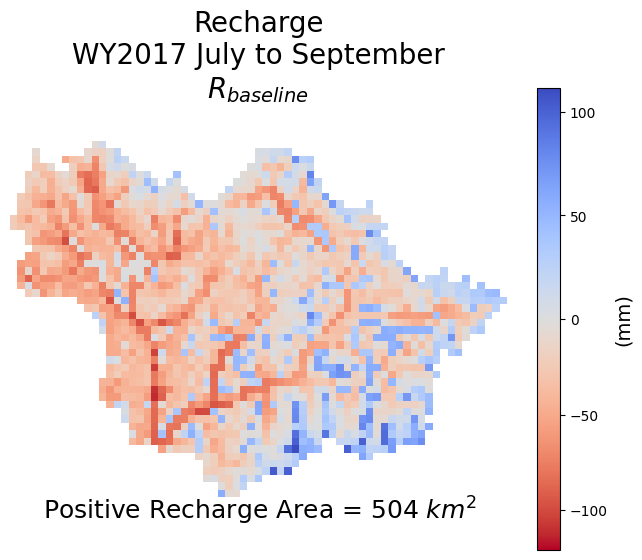

In [19]:
# how much water that infiltrates is transpired?
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

norm = colors.TwoSlopeNorm(vmin=-120.84551018067151, vcenter=0, vmax=np.nanmax(diff_infil_T)) # min from warming simulation

im = ax.imshow(np.ma.masked_array(diff_infil_T, surf_mask==0),origin='lower', norm = norm,cmap = 'coolwarm_r')
ax.axis('off')
ax.set_title('Recharge\nWY2017 July to September\n$R_{baseline}$', fontsize = 20, y = 1.1)
ax.text(4,-3.5, f"Positive Recharge Area = {recharge_area} $km^2$", fontsize = 18)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('(mm)', fontsize=14)
plt.savefig("/home/ad4430/sr_thesis/EastTaylor_outputs/WY2017_newbounds/plots/summer/map_diff_infil_T.png")
diff_infil_T.shape


In [9]:
# recharge from warming simulation
diff_infil_T_warm = np.load('/home/ad4430/sr_thesis/EastTaylor_outputs/1.5inc_WY2017_newbounds/WY2003_IC/diff_infil_T.npy')

-3.4630752326763075
-20.559710663968104
-17.0966354312918


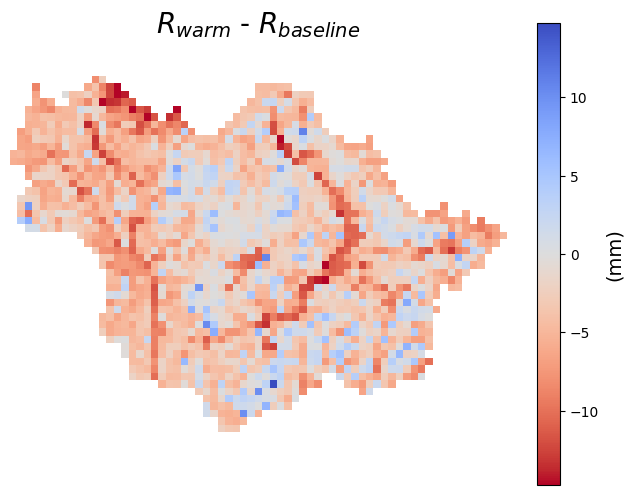

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
recharge_diff = diff_infil_T_warm- diff_infil_T
#vmin=-14.42 min from warm run
norm = colors.TwoSlopeNorm(vmin=-np.nanmax(recharge_diff), vcenter=0, vmax=np.nanmax(recharge_diff)) # min from warming simulation

im = ax.imshow(np.ma.masked_array(recharge_diff, surf_mask == 0),
               origin='lower', norm=norm, cmap='coolwarm_r')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('(mm)', fontsize=14)

ax.axis('off')
ax.set_title('$R_{warm}$ - $R_{baseline}$', fontsize=20, y=1.1)


print(np.nanmean(recharge_diff))
print(np.nanmean(diff_infil_T_warm))
print(np.nanmean(diff_infil_T))

In [28]:
recharge_neg_diff = 0
recharge_pos_diff = 0
for y in range(ny):
    for x in range(nx):
        if recharge_diff[y,x] < 0:
            recharge_neg_diff+=1
        if recharge_diff[y,x] > 0:
            recharge_pos_diff+=1
print(recharge_pos_diff)
print(recharge_pos_diff/1883)

364
0.19330855018587362


## Analysis of transpiration and recharge with elevation, WTD, and land cover

Average Transpiration by landcover (mm):
Evergreen =  100.15
Shrubland =  99.65
Deciduous =  98.95
Grassland =  47.12


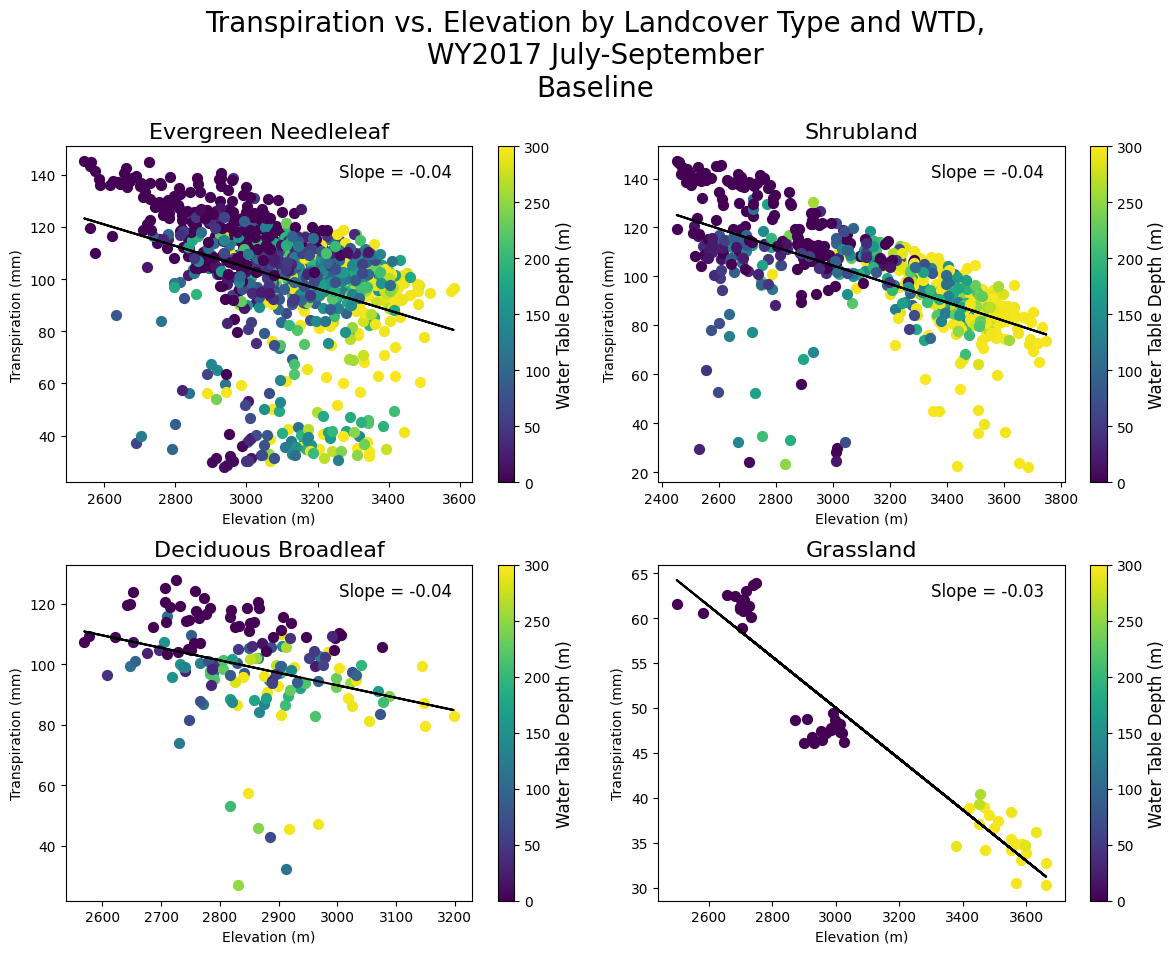

<Figure size 640x480 with 0 Axes>

In [19]:
# transpiration vs elevation for each land cover, colored by WTD
numpix_egreen = 0
numpix_shrub = 0
numpix_decbroad = 0
numpix_grass = 0

summer_tot_t_egreen = 0
summer_tot_t_shrub = 0
summer_tot_t_decbroad = 0
summer_tot_t_grass = 0

summer_transp_egreen = []
summer_transp_shrub = []
summer_transp_decbroad = []
summer_transp_grass = []

elev_egreen = []
elev_shrub = []
elev_decbroad = []
elev_grass = []

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

for y in range(1, ny): 
    for x in range(1, nx):
        elevation = dem[0, y-1, x-1]
        summer_transpiration = summer_tran_sum[y-1, x-1]
        landcover = landcover_map_masked.loc[y, x]
        summer_wtd = summer_wtd_avg[y-1, x-1] 
        
        # Evergreen Needleleaf
        if landcover == 1:
            summer_tot_t_egreen += summer_transpiration
            numpix_egreen += 1
            elev_egreen.append(elevation)
            summer_transp_egreen.append(summer_transpiration)
            axs[0, 0].scatter(elevation, summer_transpiration, s=50, c=summer_wtd, cmap='viridis', vmin = 0, vmax = 300)  # Use wtd for coloring
        
        # Shrubland
        elif landcover == 7:
            summer_tot_t_shrub += summer_transpiration
            numpix_shrub += 1
            elev_shrub.append(elevation)
            summer_transp_shrub.append(summer_transpiration)
            axs[0, 1].scatter(elevation, summer_transpiration, s=50, c=summer_wtd, cmap='viridis', vmin = 0, vmax = 300)  # Use wtd for coloring
        
        # Deciduous Broadleaf
        elif landcover == 4:
            summer_tot_t_decbroad += summer_transpiration
            numpix_decbroad += 1
            elev_decbroad.append(elevation)
            summer_transp_decbroad.append(summer_transpiration)
            axs[1, 0].scatter(elevation, summer_transpiration, s=50, c=summer_wtd, cmap='viridis', vmin = 0, vmax = 300)  # Use wtd for coloring
        
        # Grassland
        elif landcover == 10:
            summer_tot_t_grass += summer_transpiration
            numpix_grass += 1
            elev_grass.append(elevation)
            summer_transp_grass.append(summer_transpiration)
            axs[1, 1].scatter(elevation, summer_transpiration, s=50, c=summer_wtd, cmap='viridis', vmin = 0, vmax = 300)  # Use wtd for coloring

def fit_and_plot(ax, x_data, y_data):
    slope, intercept = np.polyfit(x_data, y_data, 1)  # Degree 1 for linear fit
    ax.plot(np.array(x_data), slope * np.array(x_data) + intercept, color='black')  # Plot the best-fit line in black
    return slope

summer_slope_egreen = fit_and_plot(axs[0, 0], elev_egreen, summer_transp_egreen)
summer_slope_shrub = fit_and_plot(axs[0, 1], elev_shrub, summer_transp_shrub)
summer_slope_decbroad = fit_and_plot(axs[1, 0], elev_decbroad, summer_transp_decbroad)
summer_slope_grass = fit_and_plot(axs[1, 1], elev_grass, summer_transp_grass)

axs[0, 0].text(0.95, 0.95, f'Slope = {summer_slope_egreen:.2f}', transform=axs[0, 0].transAxes, ha='right', va='top', fontsize=12, color='black')
axs[0, 1].text(0.95, 0.95, f'Slope = {summer_slope_shrub:.2f}', transform=axs[0, 1].transAxes, ha='right', va='top', fontsize=12, color='black')
axs[1, 0].text(0.95, 0.95, f'Slope = {summer_slope_decbroad:.2f}', transform=axs[1, 0].transAxes, ha='right', va='top', fontsize=12, color='black')
axs[1, 1].text(0.95, 0.95, f'Slope = {summer_slope_grass:.2f}', transform=axs[1, 1].transAxes, ha='right', va='top', fontsize=12, color='black')


summer_avg_t_egreen = summer_tot_t_egreen / numpix_egreen
summer_avg_t_shrub = summer_tot_t_shrub / numpix_shrub
summer_avg_t_decbroad = summer_tot_t_decbroad / numpix_decbroad
summer_avg_t_grass = summer_tot_t_grass / numpix_grass

print('Average Transpiration by landcover (mm):')
print('Evergreen = ', np.round(summer_avg_t_egreen, 2))
print('Shrubland = ', np.round(summer_avg_t_shrub, 2))
print('Deciduous = ', np.round(summer_avg_t_decbroad, 2))
print('Grassland = ', np.round(summer_avg_t_grass, 2))



for ax in axs.flat:
    cbar = fig.colorbar(ax.collections[0], ax=ax)  
    cbar.set_label('Water Table Depth (m)', fontsize=12)

    ax.set_xlabel('Elevation (m)', fontsize=10)
    ax.set_ylabel('Transpiration (mm)', fontsize=10)


fig.suptitle("Transpiration vs. Elevation by Landcover Type and WTD,\nWY2017 July-September\nBaseline", fontsize=20, y = 0.95)

axs[0, 0].set_title('Evergreen Needleleaf', fontsize = 16)
axs[0, 1].set_title('Shrubland', fontsize = 16)
axs[1, 0].set_title('Deciduous Broadleaf', fontsize = 16)
axs[1, 1].set_title('Grassland', fontsize = 16)

plt.tight_layout(rect=[0, 0, 1, 0.96])  

plt.show()

plt.savefig("/home/ad4430/sr_thesis/EastTaylor_outputs/WY2017_newbounds/plots/summer/summer_tranVelevation_landcover_WTD.png")

Evergreen Needleleaf: x at y=0 = 3335.80m
Shrubland: x at y=0 = 3328.94m
Deciduous Broadleaf: x at y=0 = 3342.81m
Grassland: x at y=0 = 2614.22

Average I-T by landcover (mm):
Evergreen =  -9.87
Shrubland =  -14.25
Deciduous =  -34.74
Grassland =  38.86


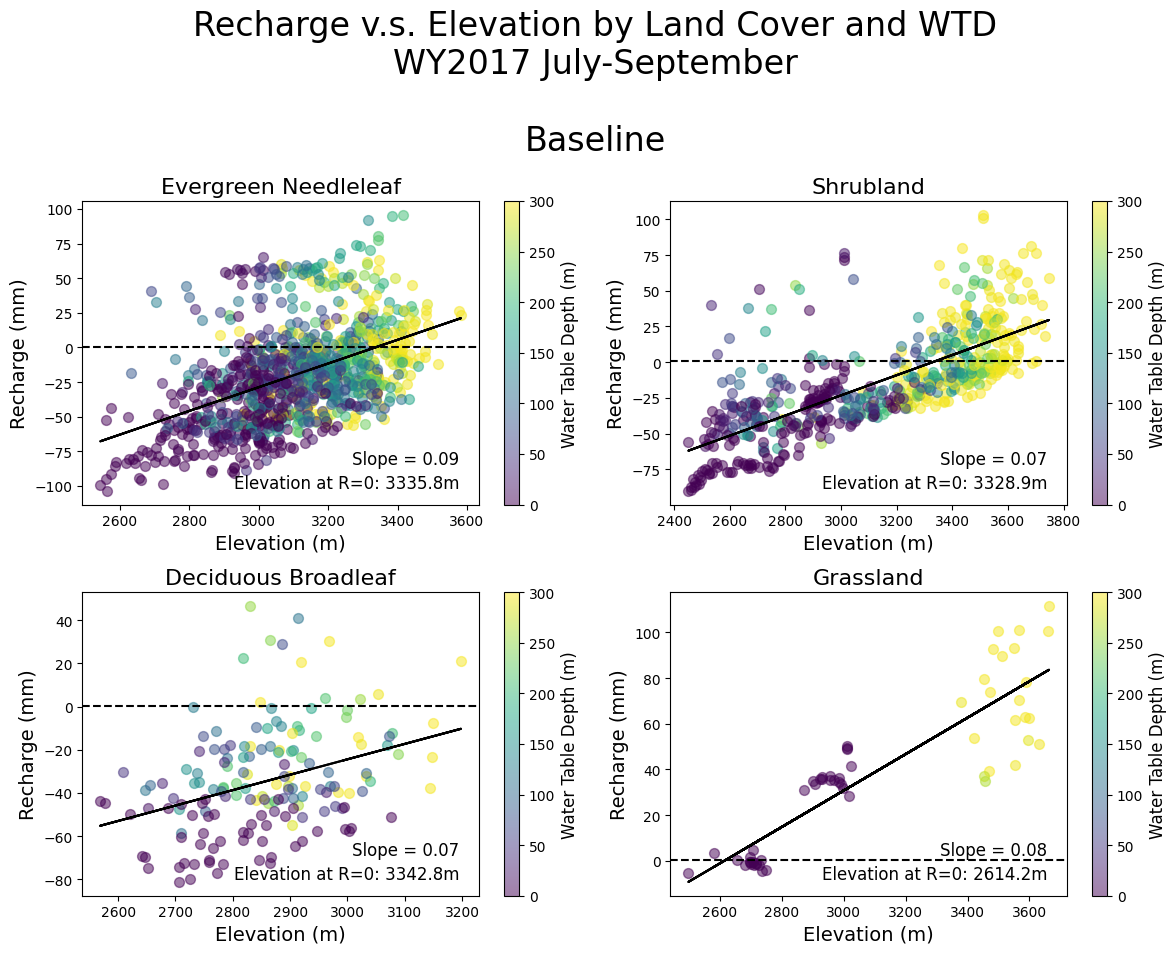

<Figure size 640x480 with 0 Axes>

In [30]:
numpix_egreen = 0
numpix_shrub = 0
numpix_decbroad = 0
numpix_grass = 0
numpix_other = 0

diff_infil_T_egreen = []
diff_infil_T_shrub = []
diff_infil_T_decbroad = []
diff_infil_T_grass = []

elev_egreen = []
elev_shrub = []
elev_decbroad = []
elev_grass = []

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

for y in range(1, ny): 
    for x in range(1, nx):
        elevation = dem[0, y-1, x-1]
        diff_infil_tran = diff_infil_T[y-1, x-1]
        landcover = landcover_map_masked.loc[y, x]
        summer_wtd = summer_wtd_avg[y-1, x-1]  # Get the water table depth for the current (y, x) location
        
        # Evergreen Needleleaf
        if landcover == 1:
            numpix_egreen += 1
            elev_egreen.append(elevation)
            diff_infil_T_egreen.append(diff_infil_tran)
            axs[0, 0].scatter(elevation,diff_infil_tran, s=50, c=summer_wtd, cmap='viridis', vmin = 0, vmax = 300, alpha = 0.5)  # Use wtd for coloring
        
        # Shrubland
        elif landcover == 7:
            numpix_shrub += 1
            elev_shrub.append(elevation)
            diff_infil_T_shrub.append(diff_infil_tran)
            axs[0, 1].scatter(elevation, diff_infil_tran, s=50, c=summer_wtd, cmap='viridis', vmin = 0, vmax = 300, alpha = 0.5)  # Use wtd for coloring
        
        # Deciduous Broadleaf
        elif landcover == 4:
            numpix_decbroad += 1
            elev_decbroad.append(elevation)
            diff_infil_T_decbroad.append(diff_infil_tran)
            axs[1, 0].scatter(elevation, diff_infil_tran, s=50, c=summer_wtd, cmap='viridis', vmin = 0, vmax = 300, alpha = 0.5)  # Use wtd for coloring
        
        # Grassland
        elif landcover == 10:
            numpix_grass += 1
            elev_grass.append(elevation)
            diff_infil_T_grass.append(diff_infil_tran)
            axs[1, 1].scatter(elevation, diff_infil_tran, s=50, c=summer_wtd, cmap='viridis', vmin = 0, vmax = 300, alpha = 0.5)  # Use wtd for coloring

        else:
            if not np.isnan(landcover_map_masked.loc[y, x]):
                numpix_other += 1


def fit_and_plot(ax, x_data, y_data):
    slope, intercept = np.polyfit(x_data, y_data, 1) 
    ax.plot(np.array(x_data), slope * np.array(x_data) + intercept, color='black')  # Plot the best-fit line in black
    x_at_zero = -intercept / slope
    return slope, intercept, x_at_zero

summer_slope_egreen, summer_intercept_egreen, x_at_zero_egreen = fit_and_plot(axs[0, 0], elev_egreen, diff_infil_T_egreen)
summer_slope_shrub, summer_intercept_shrub, x_at_zero_shrub = fit_and_plot(axs[0, 1], elev_shrub, diff_infil_T_shrub)
summer_slope_decbroad, summer_intercept_decbroad, x_at_zero_decbroad = fit_and_plot(axs[1, 0], elev_decbroad, diff_infil_T_decbroad)
summer_slope_grass, summer_intercept_grass, x_at_zero_grass = fit_and_plot(axs[1, 1], elev_grass, diff_infil_T_grass)

axs[0, 0].text(0.95, 0.10, f'Elevation at R=0: {x_at_zero_egreen:.1f}m', transform=axs[0, 0].transAxes, ha='right', va='top', fontsize=12, color='black')
axs[0, 1].text(0.95, 0.10, f'Elevation at R=0: {x_at_zero_shrub:.1f}m', transform=axs[0, 1].transAxes, ha='right', va='top', fontsize=12, color='black')
axs[1, 0].text(0.95, 0.10, f'Elevation at R=0: {x_at_zero_decbroad:.1f}m', transform=axs[1, 0].transAxes, ha='right', va='top', fontsize=12, color='black')
axs[1, 1].text(0.95, 0.10, f'Elevation at R=0: {x_at_zero_grass:.1f}m', transform=axs[1, 1].transAxes, ha='right', va='top', fontsize=12, color='black')

print(f"Evergreen Needleleaf: x at y=0 = {x_at_zero_egreen:.2f}m")
print(f"Shrubland: x at y=0 = {x_at_zero_shrub:.2f}m")
print(f"Deciduous Broadleaf: x at y=0 = {x_at_zero_decbroad:.2f}m")
print(f"Grassland: x at y=0 = {x_at_zero_grass:.2f}")


summer_slope_egreen = fit_and_plot(axs[0, 0], elev_egreen, diff_infil_T_egreen)
summer_slope_shrub = fit_and_plot(axs[0, 1], elev_shrub, diff_infil_T_shrub)
summer_slope_decbroad = fit_and_plot(axs[1, 0], elev_decbroad, diff_infil_T_decbroad)
summer_slope_grass = fit_and_plot(axs[1, 1], elev_grass, diff_infil_T_grass)

axs[0, 0].text(0.95, 0.18, f'Slope = {summer_slope_egreen[0]:.2f}', transform=axs[0, 0].transAxes, ha='right', va='top', fontsize=12, color='black')
axs[0, 1].text(0.95, 0.18, f'Slope = {summer_slope_shrub[0]:.2f}', transform=axs[0, 1].transAxes, ha='right', va='top', fontsize=12, color='black')
axs[1, 0].text(0.95, 0.18, f'Slope = {summer_slope_decbroad[0]:.2f}', transform=axs[1, 0].transAxes, ha='right', va='top', fontsize=12, color='black')
axs[1, 1].text(0.95, 0.18, f'Slope = {summer_slope_grass[0]:.2f}', transform=axs[1, 1].transAxes, ha='right', va='top', fontsize=12, color='black')

axs[0, 0].axhline(y=0.5, color='black', linestyle='--')
axs[0, 1].axhline(y=0.5, color='black', linestyle='--')
axs[1, 0].axhline(y=0.15, color='black', linestyle='--')
axs[1, 1].axhline(y=0.15, color='black', linestyle='--')

summer_avg_t_egreen = sum(diff_infil_T_egreen) / numpix_egreen
summer_avg_t_shrub = sum(diff_infil_T_shrub) / numpix_shrub
summer_avg_t_decbroad = sum(diff_infil_T_decbroad) / numpix_decbroad
summer_avg_t_grass = sum(diff_infil_T_grass) / numpix_grass

print('\nAverage I-T by landcover (mm):')
print('Evergreen = ', np.round(summer_avg_t_egreen, 2))
print('Shrubland = ', np.round(summer_avg_t_shrub, 2))
print('Deciduous = ', np.round(summer_avg_t_decbroad, 2))
print('Grassland = ', np.round(summer_avg_t_grass, 2))


for ax in axs.flat:
    cbar = fig.colorbar(ax.collections[0], ax=ax)  
    cbar.set_label('Water Table Depth (m)', fontsize=12)

    ax.set_xlabel('Elevation (m)', fontsize=14)
    ax.set_ylabel('Recharge (mm)', fontsize=14)


fig.suptitle("Recharge v.s. Elevation by Land Cover and WTD\nWY2017 July-September\n\nBaseline", fontsize=24, y = 0.95)

axs[0, 0].set_title('Evergreen Needleleaf', fontsize = 16)
axs[0, 1].set_title('Shrubland', fontsize = 16)
axs[1, 0].set_title('Deciduous Broadleaf', fontsize = 16)
axs[1, 1].set_title('Grassland', fontsize = 16)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for the suptitle

plt.show()
plt.savefig("/home/ad4430/sr_thesis/EastTaylor_outputs/WY2017_newbounds/plots/summer/diff_infl_T_landcover_WTD.png")

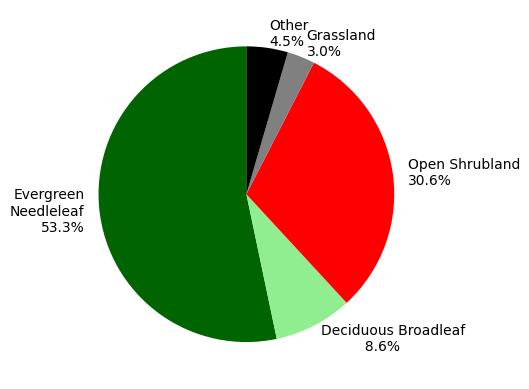

In [45]:
# land cover pie chart
numpix_total = numpix_other + numpix_egreen + numpix_shrub + numpix_grass + numpix_decbroad

per_egreen = 100*numpix_egreen/numpix_total
per_shrub = 100*numpix_shrub/numpix_total
per_decbroad = 100*numpix_decbroad/numpix_total
per_grass = 100*numpix_grass/numpix_total
per_other = 100*numpix_other/numpix_total

labels = [f'Evergreen\nNeedleleaf\n{np.round(per_egreen,1)}%', f'Deciduous Broadleaf\n          {np.round(per_decbroad,1)}%', 
          f'Open Shrubland\n{np.round(per_shrub,1)}%', f'Grassland\n{np.round(per_grass,1)}%', f'Other\n{np.round(per_other,1)}%']
sizes = [per_egreen, per_decbroad, per_shrub, per_grass, per_other]

colors = ['darkgreen', 'lightgreen', 'red', 'gray', 'black']

plt.pie(sizes, labels=labels, colors = colors, startangle=90)

plt.show()



In [35]:
# avg elevation by landcover type
dem_egreen_tot = 0
dem_decbroad_tot = 0
dem_shrub_tot = 0
dem_grass_tot = 0

temp_tot_egreen = 0
temp_tot_decbroad = 0
temp_tot_shrub = 0
temp_tot_grass = 0

for y in range(1,ny): 
    for x in range (1, nx):
        if landcover_map_masked.loc[y, x] == 1: # egreen
            dem_egreen_tot += dem[0, y-1, x-1]
            temp_tot_egreen += summer_temp_tavg[y-1, x-1]
            
        if landcover_map_masked.loc[y,x] == 4: # deciduous broadleaf
            dem_decbroad_tot += dem[0, y-1, x-1]
            temp_tot_decbroad += summer_temp_tavg[y-1, x-1]

        if landcover_map_masked.loc[y,x] == 7: # shrubland
            dem_shrub_tot += dem[0, y-1, x-1]
            temp_tot_shrub += summer_temp_tavg[y-1, x-1]

        if landcover_map_masked.loc[y,x] == 10: #grassland
            dem_grass_tot += dem[0, y-1, x-1]
            temp_tot_grass += summer_temp_tavg[y-1, x-1]

dem_egreen_avg = temp_tot_egreen/numpix_egreen
dem_decbroad_avg = temp_tot_decbroad/numpix_decbroad
dem_shrub_avg = temp_tot_shrub/numpix_shrub
dem_grass_avg = temp_tot_grass/numpix_grass

temp_egreen_avg = dem_egreen_tot/numpix_egreen
temp_decbroad_avg = dem_decbroad_tot/numpix_decbroad
temp_shrub_avg = dem_shrub_tot/numpix_shrub
temp_grass_avg = dem_grass_tot/numpix_grass

print('egreen = ',dem_egreen_avg-273.15)
print('decbroad = ', dem_decbroad_avg-273.15)
print('shrub = ',dem_shrub_avg-273.15)
print('grass = ',dem_grass_avg-273.15)

print('')

print('egreen = ',temp_egreen_avg)
print('decbroad = ', temp_decbroad_avg)
print('shrub = ',temp_shrub_avg)
print('grass = ',temp_grass_avg)

egreen =  12.741045832132897
decbroad =  14.488868912342923
shrub =  12.703869903508178
grass =  12.779227042807463

egreen =  3105.0254583606225
decbroad =  2856.0428747331134
shrub =  3127.0235534137228
grass =  3101.72919236568


In [23]:
# cumulative infiltration by land cover
infil_tot_egreen = 0
infil_tot_shrub = 0
infil_tot_decbroad = 0
infil_tot_grass = 0

for y in range(1, ny): 
    for x in range(1, nx):
        landcover = landcover_map_masked.loc[y, x]
        
        if landcover == 1:
            infil_tot_egreen+= summer_infl_sum[y-1,x-1]

        elif landcover == 7:
            infil_tot_shrub+= summer_infl_sum[y-1,x-1]

        elif landcover == 4:
            infil_tot_decbroad+= summer_infl_sum[y-1,x-1]

        elif landcover == 10:
            infil_tot_grass+= summer_infl_sum[y-1,x-1]


infil_egreen = infil_tot_egreen/numpix_egreen
infil_shrub = infil_tot_shrub/numpix_shrub
infil_decbroad = infil_tot_decbroad/numpix_decbroad
infil_grass = infil_tot_grass/numpix_grass


# total infil values
print('Total Infil by landcover (mm):')
print('Evergreen = ', np.round(infil_egreen, 2))
print('Shrubland = ', np.round(infil_shrub, 2))
print('Deciduous = ', np.round(infil_decbroad, 2))
print('Grassland = ', np.round(infil_grass, 2))


Total Infil by landcover (mm):
Evergreen =  80.41
Shrubland =  85.4
Deciduous =  64.21
Grassland =  85.98
